In [1]:
import os 
os.chdir('../../')

In [2]:
from backbones.sana import SANA

# 사용 예
model = SANA(model_id='Efficient-Large-Model/Sana_600M_512px_diffusers')
print(model)

2025-09-21 12:21:52.386009: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


Loading pipeline components...:   0%|          | 0/5 [00:00<?, ?it/s]

`torch_dtype` is deprecated! Use `dtype` instead!


Loading checkpoint shards:   0%|          | 0/2 [00:00<?, ?it/s]

In [49]:
import numpy as np
import matplotlib.pyplot as plt

def show(pil_image, dpi=200):
    plt.figure(frameon=False, dpi=dpi)   # 프레임 없는 Figure
    plt.imshow(pil_image)                # interpolation/size 건드리지 않음
    plt.axis("off")                      # xtick/ytick + 스파인 제거
    plt.tight_layout(pad=0)              # 여백 최소화
    plt.show()

In [8]:
with open('prompts/examples.txt', 'r') as f:
    PROMPTS = f.readlines()

Vibrant tropical beach at sunset, pirate ship anchored offshore, weathered wood hull, playful cartoon illustration

logs/sana/rn/s3/step_00020000.pt


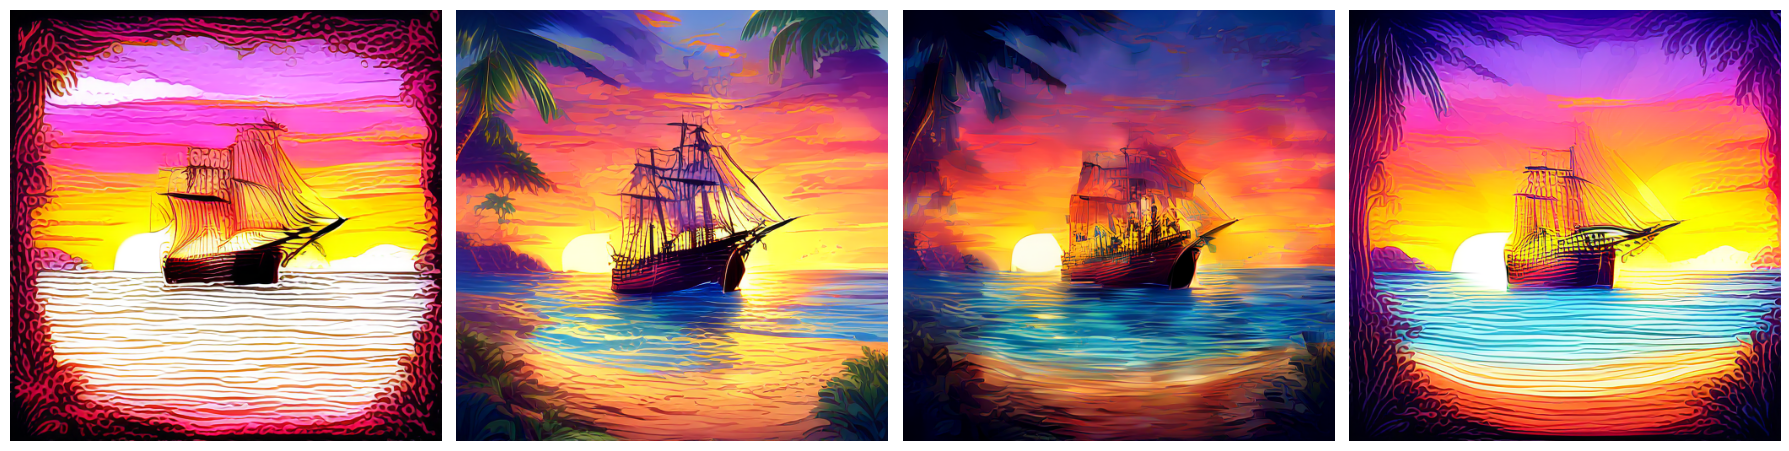

In [102]:
import torch

prompt = PROMPTS[13]
print(prompt)

noise_schedule = model.get_noise_schedule()
model_fn = model.get_model_fn(noise_schedule=noise_schedule, pos_conds=[prompt], guidance_scale=4.5)
latents = model.get_noise(seeds=[0])

NFE = 3

### DPM-Solver
from solvers.others.dpm_solver import DPM_Solver
solver = DPM_Solver(noise_schedule, steps=NFE, skip_type='time_uniform_flow', flow_shift=3.0, algorithm_type="data_prediction")
dpm_latents = solver.sample(latents, model_fn)['samples']
dpm_samples = model.decode_vae(dpm_latents, pil_output=True)

### Dual-Solver
from solvers.taylor.solver.gdual_solver import GDual_Solver
from solvers.taylor.transform.logaffine_transform import LogAffineTransform
from solvers.taylor.extractor.table_extractor import Extractor
from utils.util import get_pt

with torch.no_grad():
    gdual = GDual_Solver(noise_schedule, steps=NFE, transform=LogAffineTransform(gamma_push=True, gamma_max=2, tau_offset=1, kappa_max=2, eps=1e-2),
                        param_extractor=Extractor(steps=NFE), skip_type="time_uniform_flow", flow_shift=3.0,
                        pred_order=1, corr_order=2, order1_kappa=True, order2_kappa=True,
                        use_corrector=True, time_learning=True, train_mode=True).to(model.device)
    pt_file = get_pt(f'logs/sana/rn/s{NFE}', label='latest')
    print(pt_file)
    gdual.load_state_dict(torch.load(pt_file, map_location='cpu', weights_only=False)['solver_state_dict'], strict=True)
    dual_latents = gdual.sample(latents, model_fn)['samples']
    dual_samples = model.decode_vae(dual_latents, pil_output=True)

from solvers.competing.bns.bns_solver import BNS_Solver
from solvers.competing.ds.ds_solver_flow import DS_Solver

with torch.no_grad():
    bns = BNS_Solver(
                noise_schedule,
                steps=NFE,
                skip_type="time_uniform_flow",
                flow_shift=3.0,
                algorithm_type='vector_prediction'
            ).to(model.device)

    pt_file = get_pt(f'logs/sana/bns/s{NFE}/', label='latest')
    state_dict = torch.load(pt_file, map_location='cpu', weights_only=False)['solver_state_dict']
    bns.load_state_dict(state_dict, strict=True)
    bns_latents = bns.sample(latents, model_fn)['samples']
    bns_samples = model.decode_vae(bns_latents, pil_output=True)
    
    ds = DS_Solver(
        noise_schedule,
        steps=NFE,
        skip_type="time_uniform_flow",
        flow_shift=3.0,
        algorithm_type='vector_prediction'
    ).to(model.device)

    pt_file = get_pt(f'logs/sana/ds/s{NFE}/', label='latest')
    state_dict = torch.load(pt_file, map_location='cpu', weights_only=False)['solver_state_dict']
    ds.load_state_dict(state_dict, strict=True)
    ds_latents = ds.sample(latents, model_fn)['samples']
    ds_samples = model.decode_vae(ds_latents, pil_output=True)
    
show_compare([dpm_samples['pil_output'][0], dual_samples['pil_output'][0], bns_samples['pil_output'][0], ds_samples['pil_output'][0]])




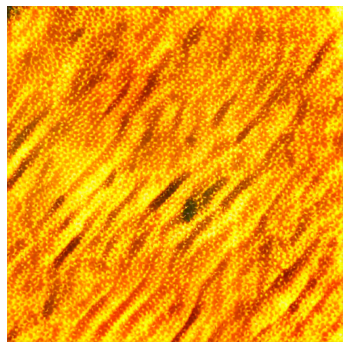

In [91]:
show(dpm_samples['pil_output'][0], dpi=70)

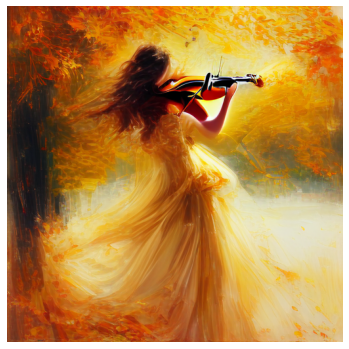

In [92]:
show(dual_samples['pil_output'][0], dpi=70)

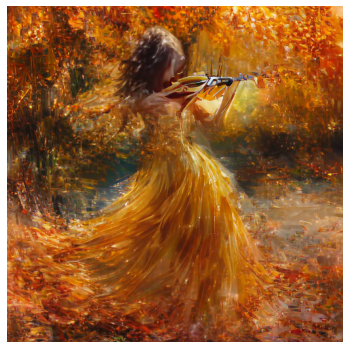

In [93]:
show(bns_samples['pil_output'][0], dpi=70)

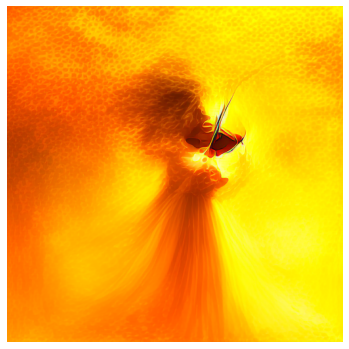

In [94]:
show(ds_samples['pil_output'][0], dpi=70)